# Monte Carlo Without Exploring Starts ($\epsilon$-greedy) implementation on Frozen Lake environment

This project implements **Monte Carlo exploring starts algorithm** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

## Environment setupm

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

lake_grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

# Monte Carlo Learning: MC $\epsilon$-greedy (without exploring starts) algorithm

### Soft policy:
- A policy is called soft if the probability to take any action is positive.
- With a soft policy, a few episodes that are sufficiently long can visit every state-action pair for sufficiently many times.
- Then, we do not need to have a large number of episodes starting from every state-action pair. Hence, the requirement of exploring starts can thus be removed.
- e-greedy is a type of soft policy. 

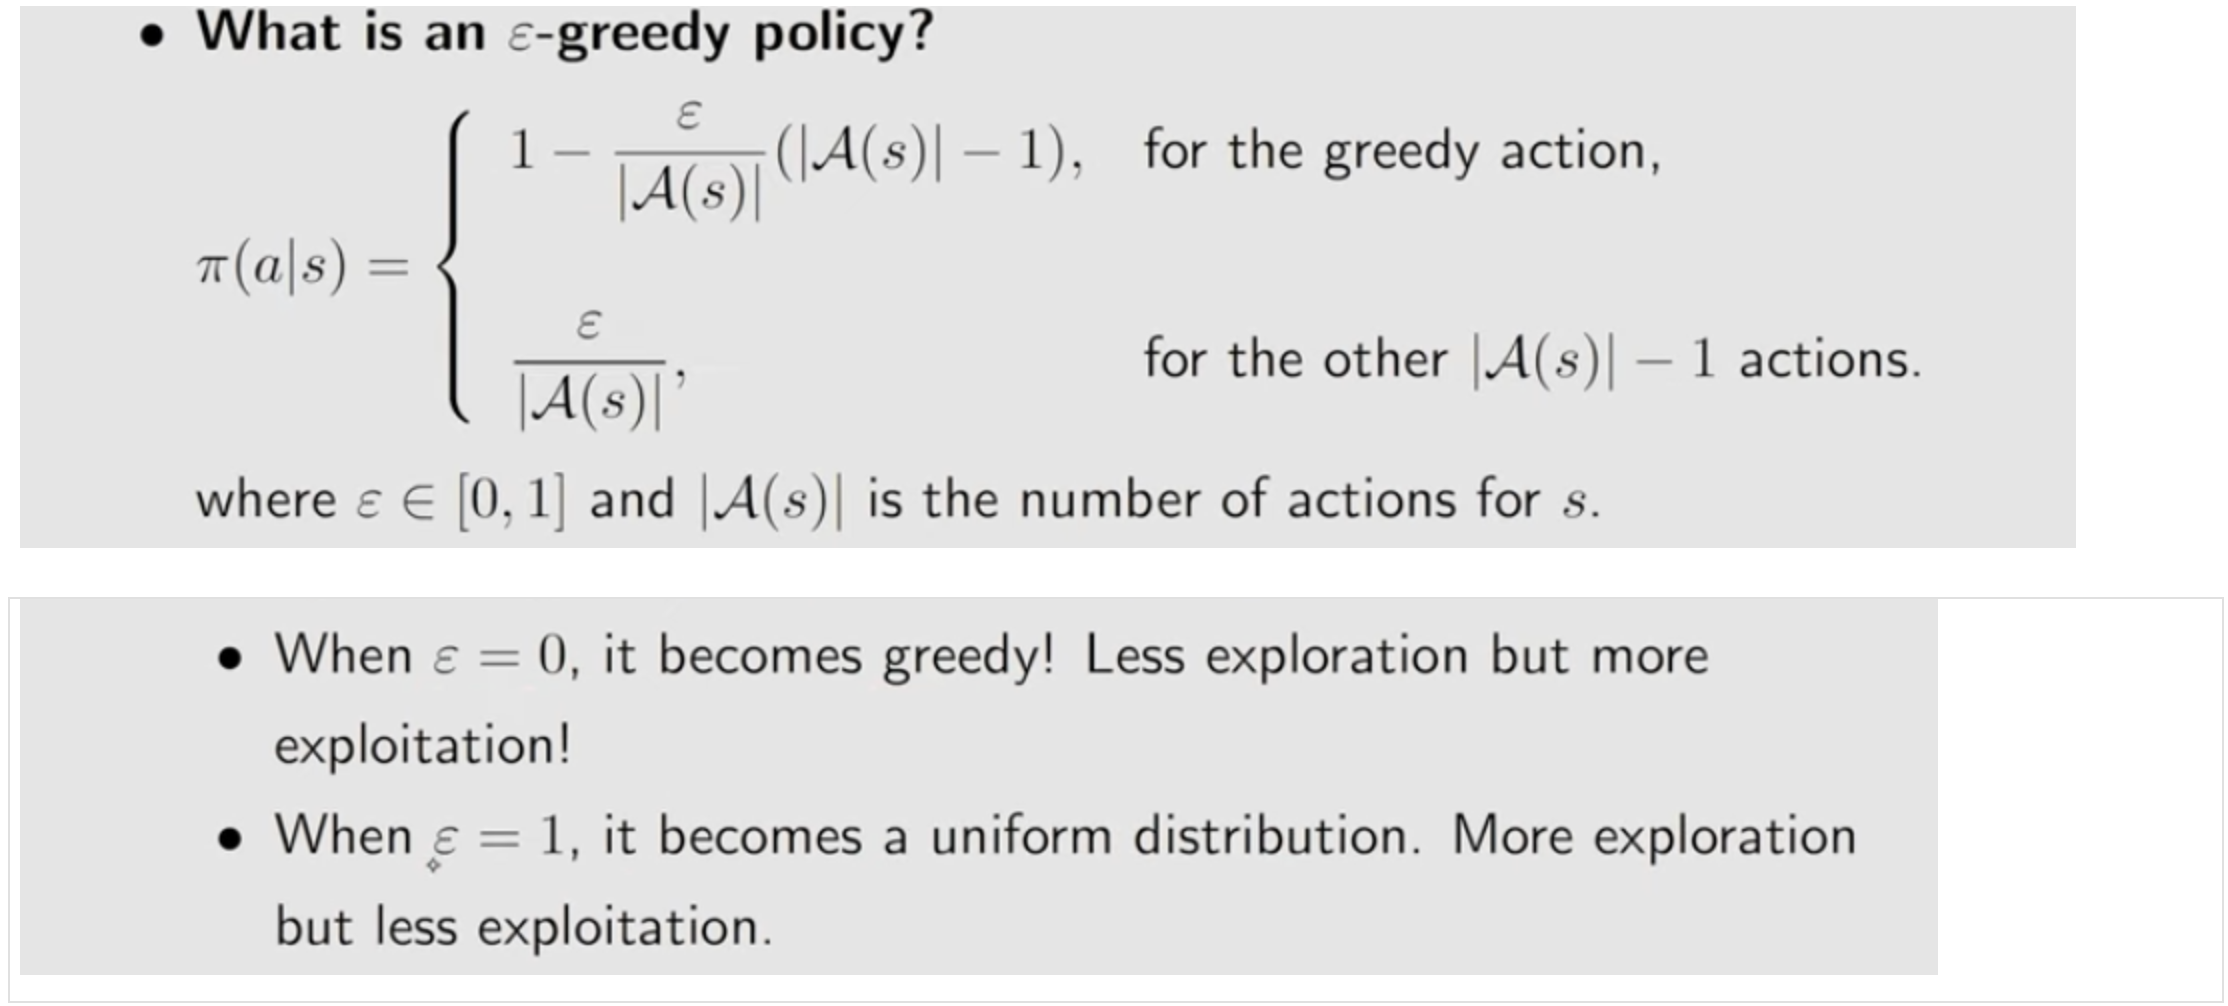

## Comparision between exploring starts and $\epsilon$-greedy MC learning

- **Exploration mechanism:**
   - Exploring Starts: Exploration is ensured by starting each episode from a randomly chosen state–action pair.
   - $\epsilon$-Greedy MC: Exploration is ensured by selecting a random action with probability $\epsilon$ at every step.

- **Policy during learning:**
  - Exploring Starts: Policy becomes fully greedy after each update.
  - $\epsilon$-Greedy MC: Policy remains stochastic ($\epsilon$-soft) during learning.

- **Exploration continuity:**
  - Exploring Starts: Exploration occurs only at the start of episodes.
  - $\epsilon$-Greedy MC: Exploration occurs throughout the entire episode.

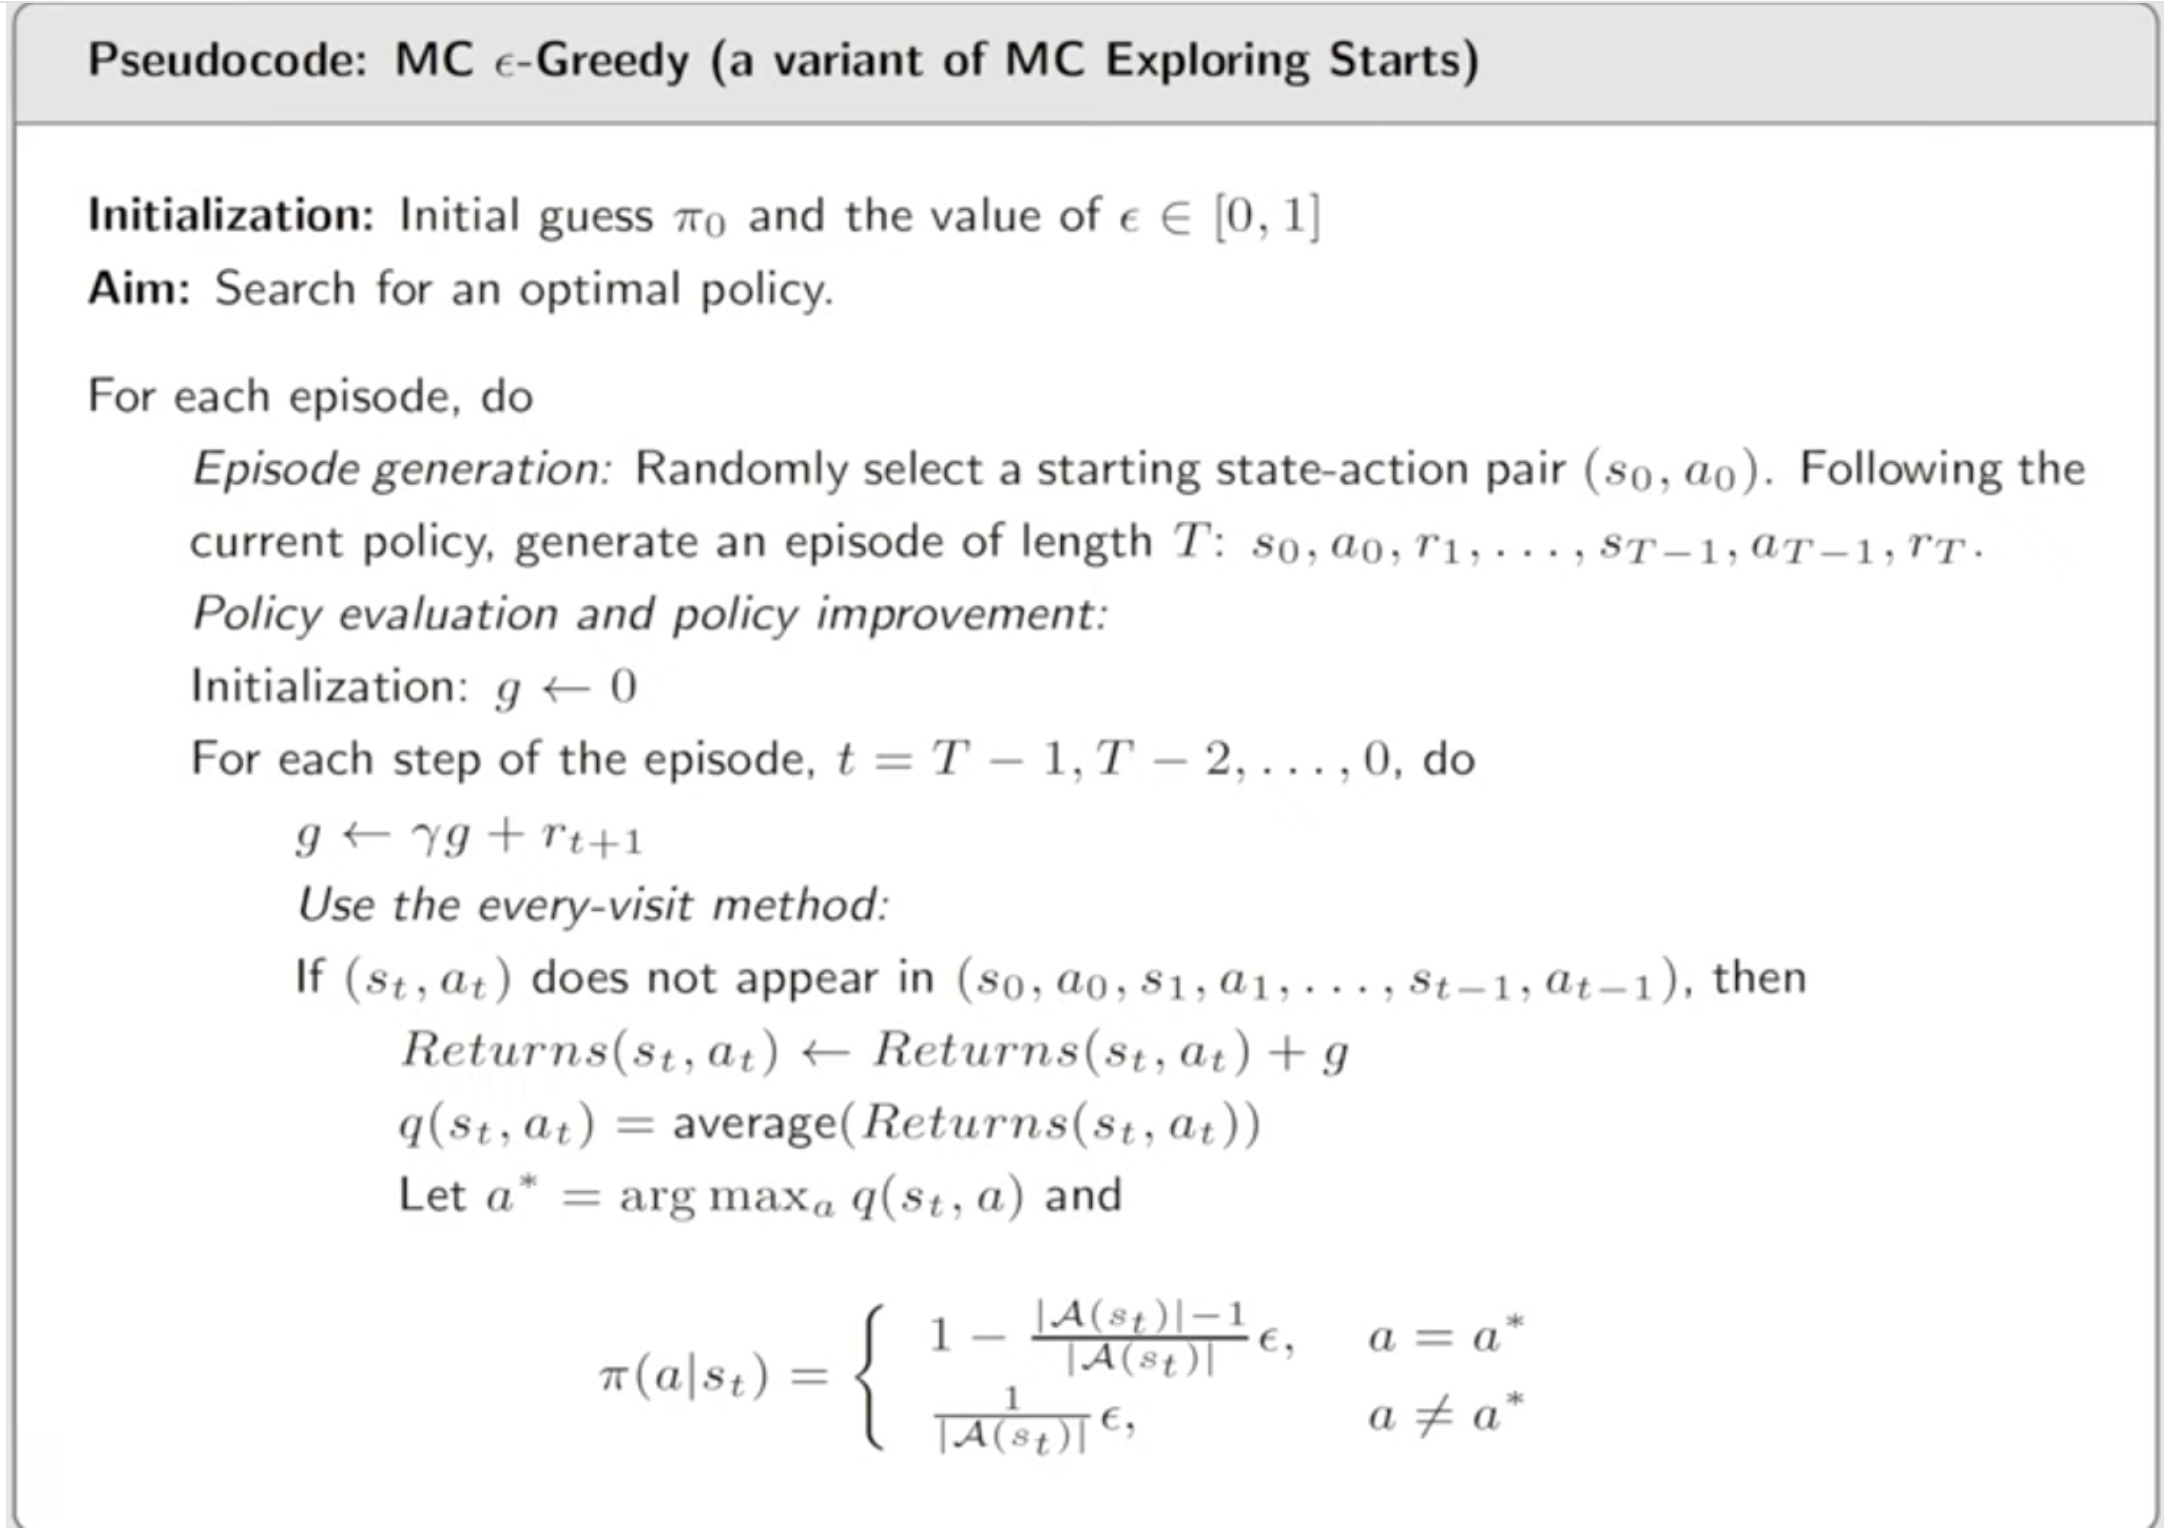

In [4]:
import random

In [5]:
def randomly_state_action_pair(state_list, action_list):
    # select element uniformly will ensure all the state, action will be selected eventually
    s = random.choice(state_list)
    a = random.choice(action_list)
    return (s, a)

In [6]:
def get_epsilon_greedy_policy(Q, state, actions, epsilon=0.2):
    if random.random() < epsilon:
        return random.choice(actions) # explore
    else:
        return np.argmax(Q[state.idx]) # exploit


def get_greedy_policy(env, Q, states):
    policy = np.zeros(env.n_states, dtype=np.int8)
    for s in states:
        policy[s.idx] = np.argmax(Q[s.idx])
    return policy.tolist()

In [7]:
def generate_episode(env, Q, state, action, max_step=1000, episode_idx=0, verbose=0):
    """
    max_step = max episode length
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    episode = []
    for step in range(max_step): 
        result = env.step(state, action)
        reward = result["reward"]
        
        episode.append((state, action, reward))
        
        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        
        action = get_epsilon_greedy_policy(Q,
                                       next_state,
                                       env.all_action_idx)

        prev_state = state
        state = next_state

        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {next_state.coord}")
        elif verbose == 2:
            states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
            
            policy = get_greedy_policy(env, Q, states_list)
            env.render(policy, state, episode_idx, step, reward)
            
        if is_terminated:
            break
            
    return episode

In [8]:
def incremental_average(last_average, x, count):
    new_average = last_average - (last_average - x)/count
    return new_average

In [9]:
def policy_evaluation_improvement(env, Q, episode, gamma, returns_count):
    visited_pair = set()
    G = 0
    
    for i in range(len(episode)-1, -1, -1): # reverse loop 
        s, a, r = episode[i]

        G = r + gamma * G
        
        # ===== first visit method =========== remove first visit condition to make it every visit
        # if (s.idx,a) in visited_pair:
            # do not update the Q table for the already visited (s,a) pair, 
            # because in first visit we only do it once in the given episode.
            # note that the averaging is done over episodes, not within the returns of the episode
            # continue
        # ====================================
        
        returns_count[s.idx][a] += 1
        
        last_mean_g = Q[s.idx][a]
        updated_mean_g = incremental_average(last_mean_g, G, returns_count[s.idx][a])

        # ---- policy improvement stage ---
        # since policy is a soft-policy, so no need to save the deterministic policy
        Q[s.idx][a] = updated_mean_g
        visited_pair.add((s.idx, a))
        
    return Q, returns_count

In [10]:
def mc_exploring_starts_run(env, n_episodes=1000, max_step=500, gamma=0.99, verbose=0):
    policy_history = []
    Q_history = []

    states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    actions_list = list(env.action_to_idx.values())
    
    policy = np.zeros(env.n_states, dtype=np.int32)    
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)

    returns_count = np.zeros((env.n_states, env.n_actions), dtype=np.int32) 
    
    for episode_idx in range(n_episodes):
        
        # since exploration is done through soft policy, 
        # no need to randomly pick the initial state actino pair like in the exploring starts method

        # --------- randomly pick initial state-action ----------
        # initial_state, initial_action = randomly_state_action_pair(states_list,
        #                                   actions_list)
        # ------------------------------------------------------

        # ---------- always pick the same initial state-action pair --------
        initial_state = env.find('S')
        initial_action = 2 #randomly picked
        # ------------------------------------------------------------------
        
        # instead of randomly selecting start state-action pair, we are going to get the initial state from the environment
        episode = generate_episode(env,
                                   Q,
                                   initial_state, 
                                   initial_action,
                                   max_step=max_step,
                                   episode_idx=episode_idx,
                                   verbose=verbose)
        
        Q, returns_count = policy_evaluation_improvement(env, Q,
                                                        episode,
                                                        gamma=gamma,
                                                        returns_count=returns_count)
    
        policy_history.append(get_greedy_policy(env, Q, states_list))
        Q_history.append(Q.tolist())
        
    return Q, policy_history, Q_history

In [11]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [12]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [13]:
frozen_lake.n_rows

4

In [14]:
Q, policy_history, Q_history = mc_exploring_starts_run(frozen_lake, n_episodes=50_000, verbose=0)

In [15]:
len(policy_history)

50000

In [16]:
policy = policy_history[-1]
policy

[2, 2, 2, 1, 2, 3, 0, 1, 2, 2, 2, 0, 0, 0, 3, 0]

In [17]:
Q

array([[1.4591509 , 5.0515513 , 5.2390933 , 5.01471   ],
       [4.5334334 , 4.881105  , 5.8394003 , 5.4453    ],
       [5.149898  , 1.9523112 , 6.5082235 , 5.500517  ],
       [6.473058  , 7.807955  , 7.4381194 , 7.2682347 ],
       [1.3785758 , 2.7488425 , 4.3949094 , 2.6918042 ],
       [2.9546099 , 4.104443  , 1.4814276 , 5.0110283 ],
       [0.        , 0.        , 0.        , 0.        ],
       [2.5936053 , 8.587734  , 7.372558  , 7.18413   ],
       [0.20512217, 1.7350501 , 4.495293  , 2.7118485 ],
       [1.8401895 , 1.2670171 , 5.39983   , 4.502135  ],
       [1.5907587 , 1.225125  , 7.8163943 , 1.9601997 ],
       [0.        , 0.        , 0.        , 0.        ],
       [1.2672163 , 0.40955156, 0.        , 0.95325893],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 4.9335823 ],
       [0.9801    , 0.        , 0.        , 0.        ]], dtype=float32)

In [18]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [19]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 2, 1],
       [2, 3, 0, 1],
       [2, 2, 2, 0],
       [0, 0, 3, 0]], dtype=int16)

In [20]:
# Render policy

In [21]:
import pandas as pd
from IPython.display import display

In [22]:
# render_policy_and_value(frozen_lake, policy, Q)
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,→,→,🚀 →,↓
1,→,↑,🕳️,↓
2,→,→,→,🏁
3,←,🕳️,↑,←


In [23]:
# Animate policy and state value history

In [24]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [25]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:]) #plotting only last 10 history
HTML(ani.to_jshtml())

In [26]:
# Let Play with different grid setup

In [27]:
grid = generate_grid_randomly(6, 6, n_holes=5)
grid

[['F', 'S', 'F', 'F', 'F', 'H'],
 ['H', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'G', 'F', 'H', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F']]

In [28]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

Q, policy_history, Q_history = mc_exploring_starts_run(frozen_lake, n_episodes=5000)

In [29]:
len(policy_history)

5000

In [30]:
policy = policy_history[-1]
print(policy)

[3, 2, 1, 1, 0, 0, 0, 3, 1, 1, 3, 1, 2, 3, 2, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0]


In [31]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3,4,5
0,↑,🚀 →,↓,↓,←,🕳️
1,🕳️,↑,↓,↓,↑,↓
2,→,↑,→,↓,←,↓
3,←,🕳️,↓,↓,←,←
4,←,←,🏁,←,🕳️,↑
5,←,🕳️,↑,↑,←,←


In [32]:
ani = animate_policy_value_video(frozen_lake, policy_history[:10])
HTML(ani.to_jshtml())

In [33]:
print("direct mean:", direct_mean)
print("rm mean: ", rm_mean)

NameError: name 'direct_mean' is not defined